# Robustez de Qudit-ADAPT-VQE frente a barren plateaus

Este cuadernillo pone a prueba la afirmación central del paper para el caso qudit:

> *ADAPT-VQE con un pool de operadores contradiabáticos es robusto frente a los efectos de barren plateau.*

La estrategia es el análogo, para **Max-3-Cut sobre qutrits**, del experimento de
Grimsley *et al.*, *npj Quantum Information* **9**, 19 (2023) — *"Adaptive,
problem-tailored variational quantum eigensolver mitigates rough parameter
landscapes and barren plateaus"*.

## La idea

CD-ADAPT-VQE construye el ansatz de a un operador por vez. Cada vez que agrega
un operador $A_{j^\*}$ del pool contradiabático, aparece un parámetro nuevo y hay
que **re-optimizar todo el ansatz**:

$$|\psi_k(\boldsymbol\theta)\rangle = e^{-i\theta_k A_k}\cdots e^{-i\theta_1 A_1}\,|\psi_0\rangle,
\qquad E_k(\boldsymbol\theta) = \langle\psi_k|H_C|\psi_k\rangle .$$

El punto clave es que ADAPT **no re-optimiza desde cero**: arranca desde los
parámetros óptimos del paso anterior más $\theta_k = 0$ para el parámetro nuevo
(*warm start* o parámetros *reciclados*). Como $\theta_k = 0$ deja el estado
intacto, ese punto de partida ya vale exactamente lo que valía el óptimo
anterior: la optimización **nunca puede empeorar**, y arranca en una región del
paisaje que ya sabe que es buena.

Lo que hacemos acá es medir cuánto importa eso. En **cada** iteración, sobre el
**mismo ansatz** de $k$ parámetros, re-optimizamos desde tres tipos de punto
inicial:

| Estrategia | Punto inicial | Qué representa |
|---|---|---|
| **Reciclada** | $(\boldsymbol\theta^{(k-1)}_{\rm opt},\, 0)$ | el algoritmo real |
| **Fría** | $\boldsymbol\theta = 0$ | reinicia el estado a $|\psi_0\rangle$ en cada paso — análogo qudit de la curva "HF" de la figura original |
| **Aleatoria** ($\times 20$) | $\theta_j \sim \mathcal U(-\pi,\pi)$ | lo que vería un ansatz de tamaño fijo sin información previa |

De cada instancia aleatoria se grafica **sólo el óptimo final**, no la
trayectoria. Es la diferencia importante: cada *dash* es entonces un mínimo del
paisaje donde efectivamente terminó una optimización, así que la columna de
$k$ parámetros muestra **la estructura de mínimos locales** que ve un ansatz de
ese tamaño. Con 20 instancias por columna esa estructura ya queda resuelta: se ve
cuántos mínimos distintos hay, cuán separados están, y cómo van apareciendo
mínimos más profundos a medida que el ansatz crece — el *burrowing* entre
mínimos que hace ADAPT.

En Max-3-Cut el espectro es discreto y muy degenerado, así que muchas
instancias caen en **exactamente** el mismo mínimo. Por eso la figura desplaza
un poco los dashes en horizontal dentro de su columna (`jitter`): sin eso, una
columna con 40 instancias en un mínimo se vería igual que una con 1.

**Cómo se lee la figura.** Si el ansatz sufriera barren plateaus o un paisaje
demasiado rugoso, la curva reciclada quedaría atrapada *dentro* de la nube de
los reinicios aleatorios. Si en cambio se despega hacia abajo y la nube se queda
arriba, el resultado es que el paisaje **sí** es rugoso (hay muchos mínimos
locales donde caer), pero ADAPT no los ve, porque el reciclaje de parámetros lo
mantiene en un valle bueno desde el principio.

## 0. Set-up

In [1]:
from pathlib import Path
import sys
import ast

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from funciones import utilidades_bp as bp

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

mpl.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.color"       : "#DDDDDD",
    "grid.linewidth"   : 0.6,
    "font.family"      : "serif",
    "font.size"        : 11,
    "axes.labelsize"   : 12,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "legend.fontsize"  : 10,
    "legend.framealpha": 0.92,
    "legend.edgecolor" : "#BBBBBB",
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "lines.linewidth"  : 2.0,
    "savefig.dpi"      : 200,
    "savefig.bbox"     : "tight",
    "savefig.facecolor": "white",
})

DATOS_DIR  = PROJECT_ROOT / "datos"
JSON_DIR   = PROJECT_ROOT / "resultados" / "json"
IMAGES_DIR = PROJECT_ROOT / "resultados" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

### Configuración del experimento

Todo el cuadernillo se controla desde este bloque. `RECOMPUTE = False` carga el
JSON ya calculado si existe; ponerlo en `True` fuerza a recalcular.

La corrida por defecto es el **grafo 2** de `datos/grafos_comparacion.txt` con
pool $\ell=2$ ($O_1 \cup O_3$), que es el caso donde CD-ADAPT-VQE converge
varias décadas — justamente el régimen donde la comparación con los reinicios
aleatorios es informativa. Con $\ell=1$ el algoritmo se estanca alrededor de
$10^{-1}$: la figura tiene mucho menos rango dinámico, pero a cambio la nube de
instancias se despliega en todas las columnas y se parece más a la figura
original.

Las dos corridas están precalculadas, así que se puede cambiar entre ellas sin
recalcular nada:

| | `GRAFO_ID` | `L` | `MAX_ITERATION` | resultado |
|---|---|---|---|---|
| **por defecto** | 2 | 2 | 30 | converge a $\sim 10^{-14}$ en 16 parámetros |
| alternativa | 1 | 1 | 20 | se estanca en $\sim 10^{-1}$ en 20 parámetros |

Ojo con `RECOMPUTE = True`: la corrida completa toma decenas de minutos con
`N_RANDOM = 20`, y varias horas con 100. Para eso conviene usar el script de `cluster/`, que corre
desatendido y guarda el JSON:

```
python cluster/main_bp.py --grafo 2 --l 2 --max_iteration 30 --n_random 20
```

In [2]:
N             = 6
INPUT_FILE    = "grafos_comparacion.txt"
GRAFO_ID      = 1
L             = 1
EPSILON       = 1e-2
MAX_ITERATION = 20
N_RANDOM      = 20
SEED          = 0

RECOMPUTE = False

NOMBRE_JSON = f"bp_n{N}_l{L}_grafo{GRAFO_ID}_r{N_RANDOM}_k{MAX_ITERATION}.json"
CMAP = "turbo"   # gradiente tipo la figura del paper; "viridis" para un ramp de un solo tono

lineas = [ln.strip() for ln in open(DATOS_DIR / INPUT_FILE) if ln.strip()]
EDGES = ast.literal_eval("[" + lineas[GRAFO_ID - 1] + "]")

print(f"Grafo {GRAFO_ID} de {INPUT_FILE}: n = {N} qutrits, {len(EDGES)} aristas")
print(EDGES)

Grafo 1 de grafos_comparacion.txt: n = 6 qutrits, 10 aristas
[(1, 2), (1, 3), (1, 4), (1, 5), (2, 4), (2, 6), (3, 4), (3, 6), (4, 5), (5, 6)]


## 1. El problema

El Hamiltoniano de costo de Max-3-Cut sobre qutrits (spin-1) es

$$H_C \;=\; \sum_{(i,j)\in E}\Big[ J_z^{(i)}J_z^{(j)} \;-\; 2\big((J_z^{(i)})^2+(J_z^{(j)})^2\big) \;+\; 3\,(J_z^{(i)})^2 (J_z^{(j)})^2 \Big],$$

y el Hamiltoniano inicial / mixer es

$$H_M \;=\; -\sum_{j} X_j, \qquad X = J_z^2 + \sqrt{2}\,J_x = \begin{pmatrix}1&1&0\\1&0&1\\0&1&1\end{pmatrix},$$

cuyo estado fundamental es la superposición uniforme $|\psi_0\rangle = 3^{-n/2}\sum_x |x\rangle$.
Ambos se construyen llamando a `Hp_qutip` y `Hi_qutip` del módulo original, así
que son exactamente los del algoritmo publicado.

In [3]:
prob = bp.prepare_problem(N, EDGES)

print(f"dimensión del espacio de Hilbert : 3^{N} = {prob['Hf_mat'].shape[0]}")
print(f"E0 exacta (fundamental de H_C)   : {prob['E0']:.10f}")
print(f"degeneración del fundamental     : {prob['ground_degeneracy']}")
print(f"gap espectral                    : {prob['spectral_gap']:.6f}")
print(f"energía inicial <psi_0|H_C|psi_0>: {prob['E_inicial']:.10f}")
print(f"error inicial                    : {abs(prob['E_inicial'] - prob['E0']):.6f}")

dimensión del espacio de Hilbert : 3^6 = 729
E0 exacta (fundamental de H_C)   : -20.0000000000
degeneración del fundamental     : 12
gap espectral                    : 2.000000
energía inicial <psi_0|H_C|psi_0>: -13.3333333333
error inicial                    : 6.666667


## 2. Verificación del motor numérico

Antes de sacar conclusiones sobre barren plateaus conviene demostrar que el
motor de este cuadernillo es el mismo algoritmo del repositorio. `utilidades_bp`
reimplementa la parte pesada en `numpy`/`scipy.sparse` con **gradiente
analítico** (retropropagación sobre el producto de exponenciales) en vez de las
diferencias finitas que usa `minimize` por defecto en `utilidades.py`.

Esa diferencia es deliberada: en un estudio de barren plateaus lo que se mide
son gradientes, y no se quiere que el optimizador se detenga por ruido de
diferencias finitas en vez de por la geometría real del paisaje. El objetivo
matemático es idéntico.

Tres chequeos:
1. el pool contradiabático es idéntico, operador por operador, al de `cd_adapt_vqe_algorithm_profundo`;
2. el gradiente analítico coincide con diferencias finitas;
3. la curva reciclada reproduce el `energy_trace` del algoritmo original.

In [4]:
# --- 1. el pool es el mismo -------------------------------------------------
import sympy as sp
from funciones.utilidades import (Had, dHad_dlam, nested_commutators, canonical_op,
                                  cd_adapt_vqe_algorithm_profundo)

lam = sp.symbols("lam", real=True)
O_repo = nested_commutators(Had(N, EDGES, lam), dHad_dlam(N, EDGES), order=3)
labels_repo = sorted({canonical_op(o) for o in O_repo[1].keys()}, key=str)
if L == 2:
    labels_repo = labels_repo + sorted({canonical_op(o) for o in O_repo[3].keys()}, key=str)
labels_repo = [str(o) for o in labels_repo]

pool = bp.build_cd_pool(N, EDGES, L)
print(f"pool l={L}: {len(pool['labels'])} operadores")
print(f"idéntico al del algoritmo original: {labels_repo == pool['labels']}")

pool l=1: 46 operadores
idéntico al del algoritmo original: True


In [5]:
# --- 2. gradiente analítico vs diferencias finitas --------------------------
A_sparse, _ = bp.pool_to_sparse(pool["ops"], prob["Hf_sparse"])
rng = np.random.default_rng(1234)

idxs     = list(rng.integers(0, len(A_sparse), size=6))
A_ansatz = [A_sparse[i] for i in idxs]
spectra  = [bp.operator_spectrum(A_sparse[i]) for i in idxs]
theta    = rng.uniform(-np.pi, np.pi, size=len(idxs))

g_ana, g_num, err = bp.verificar_gradiente(theta, spectra, A_ansatz,
                                           prob["psi0"], prob["Hf_mat"])
print("gradiente analítico  :", np.round(g_ana, 8))
print("diferencias finitas  :", np.round(g_num, 8))
print(f"error máximo         : {err:.3e}   ->  {'OK' if err < 1e-5 else 'FALLA'}")

gradiente analítico  : [-0.21352344 -0.13311242  0.28599868 -0.22443134 -0.57767372  0.10892516]
diferencias finitas  : [-0.21352344 -0.13311243  0.28599868 -0.22443134 -0.57767372  0.10892516]
error máximo         : 1.468e-09   ->  OK


El tercer chequeo (la curva reciclada contra `cd_adapt_vqe_algorithm_profundo`)
se corre sobre un caso chico para que sea rápido: $n=4$ con $\ell=1$. Los
índices de operador pueden diferir porque en grafos simétricos varios
operadores empatan en el gradiente hasta $\sim 10^{-15}$ y `argmax` rompe el
empate según el último bit; los operadores son equivalentes por simetría y las
energías coinciden.

In [6]:
# --- 3. la curva reciclada es el algoritmo original -------------------------
n_test, edges_test = 4, [(1, 2), (1, 3), (2, 4), (3, 4)]

res_repo = cd_adapt_vqe_algorithm_profundo(n_test, edges_test, l=1,
                                           epsilon=1e-2, max_iteration=8, show=False)
res_bp = bp.adapt_bp_scan(n_test, edges_test, l=1, epsilon=1e-2, max_iteration=8,
                          n_random=2, seed=0, show=False)

err_repo = np.array(res_repo["energy_trace"][:9]) - res_repo["ground_energy"]
err_bp   = np.array(res_bp["recycled_energy"])   - res_bp["ground_energy"]

print("error |E-E0|, algoritmo original :", np.round(err_repo, 10))
print("error |E-E0|, curva reciclada    :", np.round(err_bp, 10))
print(f"desviación máxima: {np.max(np.abs(err_repo - err_bp)):.3e}")

error |E-E0|, algoritmo original : [2.66666667 2.26034953 1.71859334 0.59768051 0.38722485 0.32703194
 0.28875351 0.28361489 0.26220219]
error |E-E0|, curva reciclada    : [2.66666667 2.26034953 1.71859334 0.59768051 0.38722485 0.32703194
 0.28875351 0.28361489 0.26220219]
desviación máxima: 5.960e-11


## 3. El experimento

En cada iteración de ADAPT: se elige el operador de mayor gradiente, se agrega
al ansatz, y el mismo ansatz se re-optimiza desde el warm start reciclado, desde
$\theta=0$, y desde `N_RANDOM` puntos uniformemente aleatorios en $[-\pi,\pi]$,
guardando la historia completa del coste en cada caso.

Esta celda es la cara: con la configuración por defecto tarda del orden de una
hora. Si el JSON ya existe, se carga.

In [7]:
ruta_json = JSON_DIR / NOMBRE_JSON

if ruta_json.exists() and not RECOMPUTE:
    res = bp.load_bp_result(ruta_json)
    print(f"Cargado desde {ruta_json.name}")
elif not ruta_json.exists() and not RECOMPUTE:
    disponibles = sorted(p.name for p in JSON_DIR.glob("*.json"))
    raise FileNotFoundError(
        f"No existe {NOMBRE_JSON}. Con N_RANDOM={N_RANDOM} recalcular toma horas,\n"
        f"así que conviene correr el script de cluster/ en vez de esta celda:\n\n"
        f"    python cluster/main_bp.py --grafo {GRAFO_ID} --l {L} "
        f"--max_iteration {MAX_ITERATION} --n_random {N_RANDOM}\n\n"
        f"JSONs disponibles: {disponibles}\n"
        f"(o poné RECOMPUTE = True para calcularlo acá igual)"
    )
else:
    res = bp.adapt_bp_scan(
        n=N, edges=EDGES, l=L,
        epsilon=EPSILON, max_iteration=MAX_ITERATION,
        n_random=N_RANDOM, seed=SEED, show=True,
    )
    res["input_file"] = INPUT_FILE
    res["grafo_id"]   = GRAFO_ID
    bp.save_bp_result(res, NOMBRE_JSON)
    print(f"Guardado en {ruta_json.name}")

print(f"\noperadores en el ansatz : {res['num_ansatz_ops']}")
print(f"razón de parada         : {res['stop_reason']}")
print(f"tamaño del pool         : {res['pool_size']}")
print(f"tiempo de cómputo       : {res['runtime_min']:.1f} min")

Cargado desde bp_n6_l1_grafo1_r20_k20.json

operadores en el ansatz : 20
razón de parada         : max_iteration_reached
tamaño del pool         : 46
tiempo de cómputo       : 24.8 min


## 4. La figura

Cada *dash* es el **óptimo final** de una de las 20 instancias aleatorias, para
un ansatz de ese número de parámetros. El color va en gradiente con la magnitud
del error — redundante con la posición vertical, sirve para leer la densidad de
la nube, igual que en la figura original.

Al lado va el grafo del problema, dibujado como hexágono con el sitio 1 arriba
y numerado en sentido antihorario, con los vértices coloreados según la
solución Max-3-Cut que encontró el algoritmo. Como el fundamental de $H_C$ es
degenerado (todas las coloraciones óptimas y sus permutaciones de color), el
estado convergido es una superposición de muchas soluciones equivalentes: la
que se muestra es la del estado de la base computacional **más probable**, es
decir el resultado más probable de medir el circuito.

**Cómo leer el grafo.** Cada vértice es un qutrit y su color indica a cuál de
las **tres clases** lo asignó la solución. Una arista está *cortada* si sus dos
extremos quedaron de colores distintos — y Max-3-Cut consiste justamente en
maximizar cuántas aristas quedan cortadas.

- **Rojo sólido**: aristas cortadas. Son las que cuentan para la función
  objetivo.
- **Gris punteado**: aristas monocromáticas, con ambos extremos del mismo
  color. No aportan.

El título dice cuántas de las aristas totales quedaron cortadas. Ese número se
verifica de forma independiente contra el espectro exacto: con la convención de
$H_p$ cada arista cortada aporta $-2$ y cada monocromática $0$, así que el
máximo alcanzable es $|E_0|/2$. Cuando el grafo es 3-coloreable se cortan
todas; cuando no lo es, quedan algunas monocromáticas necesariamente, y ninguna
coloración con tres clases puede hacerlo mejor.

Solución Max-3-Cut encontrada:
  coloreo (sitio -> clase) : {1: 1, 2: 0, 3: 0, 4: 2, 5: 0, 6: 1}
  aristas cortadas         : 10 / 10
  máximo alcanzable        : 10  (= |E0|/2)
  ¿es óptima?              : True
  energía del coloreo      : -20.0  (E0 = -20.0)

Figura guardada en:
  /home/hd/workspace/Qudit-ADAPT/resultados/images/bp_landscape_n6_l1_grafo1.pdf
  /home/hd/workspace/Qudit-ADAPT/resultados/images/bp_landscape_n6_l1_grafo1.png


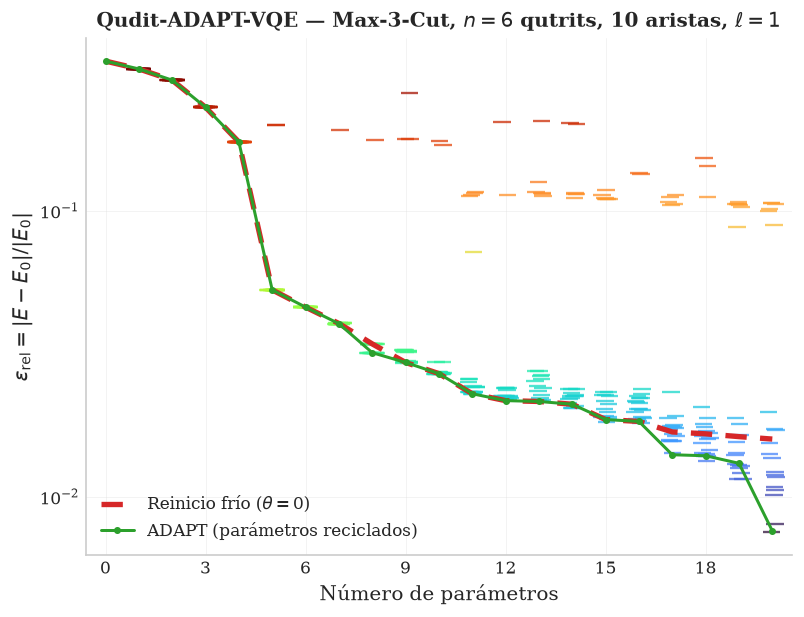

In [8]:
fig, ax_main = plt.subplots(figsize=(7.6, 5.6))
bp.plot_bp_landscape(res, ax=ax_main, cmap=CMAP, mode="final",
                     inset_grafo=False, relativo=True)
sol = bp.solucion_max3cut(res)

salida_pdf = IMAGES_DIR / f"bp_landscape_n{N}_l{L}_grafo{GRAFO_ID}.pdf"
salida_png = salida_pdf.with_suffix(".png")
fig.savefig(salida_pdf)
fig.savefig(salida_png)

print(f"Solución Max-3-Cut encontrada:")
print(f"  coloreo (sitio -> clase) : {sol['coloreo']}")
print(f"  aristas cortadas         : {sol['num_cortadas']} / {len(EDGES)}")
print(f"  máximo alcanzable        : {sol['max_corte']}  (= |E0|/2)")
print(f"  ¿es óptima?              : {sol['es_optima']}")
print(f"  energía del coloreo      : {sol['energia_del_coloreo']}  (E0 = {res['ground_energy']})")
if sol["aristas_monocromaticas"]:
    print(f"  aristas sin cortar       : {sol['aristas_monocromaticas']}")
print(f"\nFigura guardada en:\n  {salida_pdf}\n  {salida_png}")
plt.show()

## 5. Qué compuertas eligió el ansatz

El ansatz final es

$$|\psi\rangle = e^{-i\theta_m G_m}\cdots e^{-i\theta_2 G_2}\,e^{-i\theta_1 G_1}\,|\psi_0\rangle,$$

donde cada $G_k$ es el operador que ADAPT sacó del pool contradiabático en el
paso $k$. Vale la pena mirar su forma explícita, porque muestra qué estructura
física está eligiendo el algoritmo.

**Cuidado con un detalle.** El pool guarda *monomios* de momento angular, como
`((1,'y'), (2,'z'))`, pero el operador que entra al ansatz es la parte
hermítica $G = (O + O^\dagger)/2$ (ver `pool_to_qutip`). Hay dos casos:

- **Factores en sitios distintos:** conmutan, así que $O$ ya es hermítico y
  $G = O$. Por ejemplo $G = L_y^{(3)} L_z^{(6)}$.
- **Dos ejes distintos en el mismo sitio:** ahí $L_a^{(s)}$ y $L_b^{(s)}$ no
  conmutan, $O$ no es hermítico, y la simetrización deja un anticonmutador:
  $G = \tfrac12\{L_y^{(1)}, L_z^{(1)}\}$.

Escribir $G = L_y^{(1)} L_z^{(1)}$ en ese segundo caso sería incorrecto — no es
hermítico y $e^{-i\theta G}$ no sería unitaria.

In [9]:
n_ver, err_ver = bp.verificar_gate_expressions(res)
print(f"{n_ver} generadores reconstruidos desde su etiqueta y comparados "
      f"contra el operador del pool")
print(f"error máximo: {err_ver:.3e}  ->  {'OK' if err_ver < 1e-10 else 'FALLA'}")

20 generadores reconstruidos desde su etiqueta y comparados contra el operador del pool
error máximo: 0.000e+00  ->  OK


In [10]:
gates = bp.ansatz_gates(res, latex=False)

print(f"Ansatz de {len(gates)} compuertas (orden de aplicación):\n")
for g in gates:
    marca = "" if g["hermitico_directo"] else "   <- mismo sitio: anticonmutador"
    print(f"  {g['step']:2d} | theta = {g['theta']:+.6f} | {g['gate']}{marca}")

n_sim = sum(1 for g in gates if not g["hermitico_directo"])
sitios = sorted({s for g in gates for s in g["sitios"]})
print(f"\n{n_sim}/{len(gates)} generadores requieren simetrización")
print(f"sitios involucrados: {sitios}")

Ansatz de 20 compuertas (orden de aplicación):

   1 | theta = +1.479086 | exp(-i·θ·[Ly(3) · Lz(6)])
   2 | theta = +1.647619 | exp(-i·θ·[Lz(3) · Ly(4)])
   3 | theta = +1.570796 | exp(-i·θ·[Ly(2) · Lz(4)])
   4 | theta = +1.453711 | exp(-i·θ·[Lz(4) · Ly(5)])
   5 | theta = +3.141593 | exp(-i·θ·[½{Ly(1), Lz(1)} · Lz(4)^2])   <- mismo sitio: anticonmutador
   6 | theta = +1.704199 | exp(-i·θ·[Ly(3) · Lz(4)])
   7 | theta = -0.091290 | exp(-i·θ·[Lz(2) · Ly(6)])
   8 | theta = -1.595473 | exp(-i·θ·[Ly(3) · Lz(6)])
   9 | theta = -0.041160 | exp(-i·θ·[Lz(5) · Ly(6)])
  10 | theta = -1.230959 | exp(-i·θ·[½{Ly(1), Lz(1)}])   <- mismo sitio: anticonmutador
  11 | theta = +1.937099 | exp(-i·θ·[½{Ly(6), Lz(6)} · Lz(3)^2])   <- mismo sitio: anticonmutador
  12 | theta = -0.003315 | exp(-i·θ·[Lz(2) · Ly(6)])
  13 | theta = -0.182287 | exp(-i·θ·[Ly(3) · Lz(6)])
  14 | theta = -0.515045 | exp(-i·θ·[Lz(3) · Ly(6)])
  15 | theta = +1.571352 | exp(-i·θ·[Lz(1) · Ly(2)])
  16 | theta = -1.224081 | exp(-

La misma información en LaTeX, lista para pegar en el paper:

In [11]:
from IPython.display import Latex, display

print(bp.ansatz_latex(res, max_pasos=6))
display(Latex(r"$$\begin{aligned}" + bp.ansatz_latex(res, max_pasos=6) + r"\end{aligned}$$"))

|\psi\rangle = e^{-i\theta_{6} G_{6}}\,e^{-i\theta_{5} G_{5}}\,e^{-i\theta_{4} G_{4}}\,e^{-i\theta_{3} G_{3}}\,e^{-i\theta_{2} G_{2}}\,e^{-i\theta_{1} G_{1}}\,|\psi_0\rangle
\\[0.6em]
G_{1} &= L_y^{(3)}\,L_z^{(6)}, \qquad \theta_{1} = 1.479086 \\
G_{2} &= L_z^{(3)}\,L_y^{(4)}, \qquad \theta_{2} = 1.647619 \\
G_{3} &= L_y^{(2)}\,L_z^{(4)}, \qquad \theta_{3} = 1.570796 \\
G_{4} &= L_z^{(4)}\,L_y^{(5)}, \qquad \theta_{4} = 1.453711 \\
G_{5} &= \tfrac{1}{2}\left\{L_y^{(1)},\, L_z^{(1)}\right\}\,\left(L_z^{(4)}\right)^{2}, \qquad \theta_{5} = 3.141593 \\
G_{6} &= L_y^{(3)}\,L_z^{(4)}, \qquad \theta_{6} = 1.704199 \\


<IPython.core.display.Latex object>

## 6. Diagnóstico complementario: los gradientes

Acá hay que tener cuidado con qué mide cada cosa, porque es fácil sacar una
conclusión que los datos no sostienen.

**Panel (a): gradientes de selección de ADAPT.** Son los $|g_j| = |\langle\psi_k|[H_C,A_j]|\psi_k\rangle|$
que el algoritmo usa para elegir el siguiente operador, a lo largo de su propia
trayectoria. Estos gradientes **bajan**, pero eso no dice nada sobre barren
plateaus: bajan porque el algoritmo se está acercando al mínimo, que es
exactamente lo que uno quiere que pase. Es una traza de convergencia.

**Panel (b): el diagnóstico de verdad.** Un barren plateau no es que el
gradiente baje cerca del óptimo, sino que el paisaje sea exponencialmente plano
**en puntos de parámetros aleatorios**, de modo que un optimizador sin
información previa no tenga señal que seguir. La firma es que
$\mathrm{Var}(\partial E/\partial\theta_j)$ decaiga exponencialmente al crecer
el circuito. Por eso reevaluamos el gradiente exacto en los mismos puntos
iniciales aleatorios $\theta^0$ que usaron los reinicios del experimento, para
cada tamaño de ansatz. En escala log, un barren plateau se vería como una
recta descendente.

Una advertencia de alcance: lo que se barre acá es la **profundidad** del
circuito a $n=6$ fijo. La definición estricta de barren plateau es sobre el
escalamiento con el **número de qudits** $n$, así que la evidencia concluyente
requeriría repetir esto para $n = 4,5,6,7,\dots$ y ver cómo escala la varianza.
Eso queda como el paso siguiente natural.

Figura guardada en: /home/hd/workspace/Qudit-ADAPT/resultados/images/bp_gradientes_n6_l1_grafo1.pdf


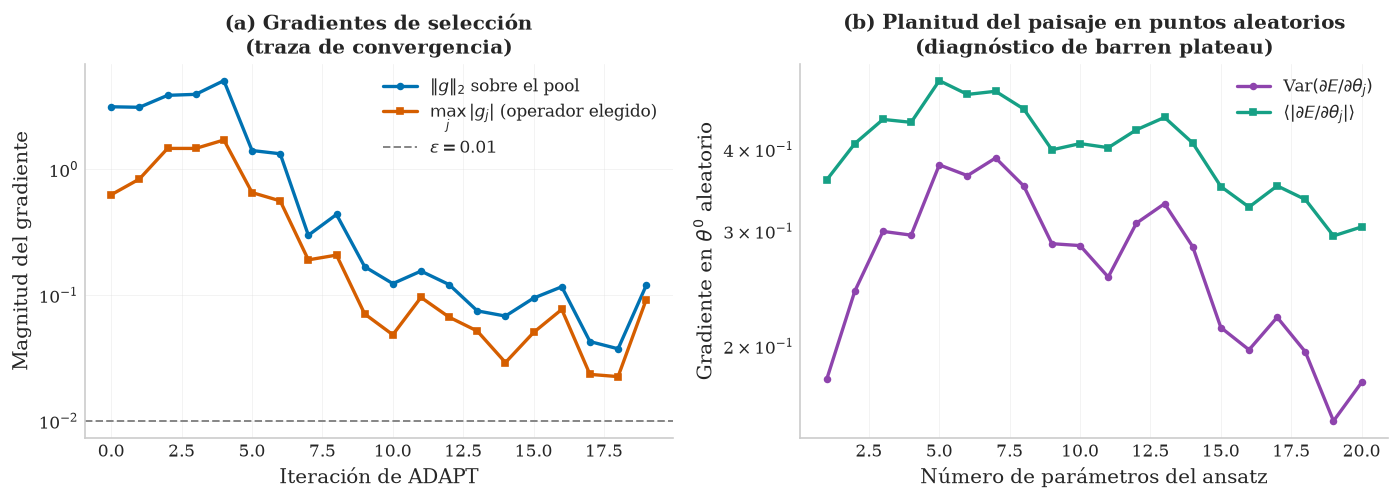

In [12]:
grad_stats = bp.gradient_stats_at_random_inits(res)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3))
bp.plot_bp_gradients(res, stats=grad_stats, axes=axes)
fig.tight_layout()

salida_grad = IMAGES_DIR / f"bp_gradientes_n{N}_l{L}_grafo{GRAFO_ID}.pdf"
fig.savefig(salida_grad)
fig.savefig(salida_grad.with_suffix(".png"))

print(f"Figura guardada en: {salida_grad}")
plt.show()

In [13]:
# ¿decae la varianza exponencialmente con la profundidad del circuito?
k  = grad_stats["k"]
lv = np.log(grad_stats["var"])
pendiente, _ = np.polyfit(k, lv, 1)

print(f"Var(dE/dtheta) en theta^0 aleatorio:")
print(f"  con  {k[0]:2d} parámetros : {grad_stats['var'][0]:.4e}")
print(f"  con  {k[-1]:2d} parámetros : {grad_stats['var'][-1]:.4e}")
print(f"  razón                 : {grad_stats['var'][0] / grad_stats['var'][-1]:.2f}x")
print(f"\n  ajuste log-lineal: Var ~ exp({pendiente:+.4f} k)")
print(f"  -> vida media de {np.log(2)/abs(pendiente):.1f} parámetros" if pendiente < 0
      else "  -> sin decaimiento")

Var(dE/dtheta) en theta^0 aleatorio:
  con   1 parámetros : 1.7790e-01
  con  20 parámetros : 1.7606e-01
  razón                 : 1.01x

  ajuste log-lineal: Var ~ exp(-0.0244 k)
  -> vida media de 28.4 parámetros


## 7. Resumen cuantitativo

Números para citar en el texto. La comparación honesta es contra la
**distribución completa** de los reinicios aleatorios, no contra el mejor de
los diez: con suficientes reinicios, alguno puede tener suerte y caer en la
cuenca correcta. Lo que distingue a ADAPT es que llega ahí **siempre**, sin
depender del sorteo.

In [14]:
import pandas as pd

curvas = bp.bp_error_curves(res)

tabla = pd.DataFrame({
    "k"                : curvas["k"],
    "reciclada"        : curvas["recycled"],
    "fría (theta=0)"   : curvas["cold"],
    "mejor aleat."     : curvas["best_random"],
    "mediana aleat."   : curvas["median_random"],
    "peor aleat."      : curvas["worst_random"],
})
tabla["mediana / reciclada"] = tabla["mediana aleat."] / tabla["reciclada"]

pd.set_option("display.float_format", lambda v: f"{v:.3e}")
display(tabla.tail(20))

,k,reciclada,fría (theta=0),mejor aleat.,mediana aleat.,peor aleat.,mediana / reciclada
1,1,6.260e+00,6.260e+00,6.260e+00,6.260e+00,6.260e+00,1.000e+00
2,2,5.719e+00,5.719e+00,5.719e+00,5.719e+00,5.719e+00,1.000e+00
3,3,4.598e+00,4.598e+00,4.598e+00,4.598e+00,4.598e+00,1.000e+00
4,4,3.477e+00,3.477e+00,3.477e+00,3.477e+00,3.477e+00,1.000e+00
5,5,1.057e+00,1.057e+00,1.057e+00,1.057e+00,3.990e+00,1.000e+00
6,6,9.201e-01,9.201e-01,9.201e-01,9.201e-01,9.201e-01,1.000e+00
7,7,8.052e-01,8.067e-01,8.052e-01,8.052e-01,3.830e+00,1.000e+00
8,8,6.377e-01,6.844e-01,6.377e-01,6.844e-01,3.537e+00,1.073e+00
9,9,5.894e-01,5.894e-01,5.892e-01,6.403e-01,5.174e+00,1.086e+00
10,10,5.388e-01,5.388e-01,5.383e-01,5.430e-01,3.515e+00,1.008e+00


In [15]:
E0 = res["ground_energy"]
finales = np.abs(np.array([r["final_energy"] for r in res["random_runs"][-1]]) - E0)
k_fin = int(curvas["k"][-1])

TOL = 1e-6
n_ok = int(np.sum(finales < TOL))

print(f"Ansatz final ({k_fin} parámetros, {res['n_random']} reinicios aleatorios):\n")
print(f"  ADAPT (reciclada)       : {curvas['recycled'][-1]:.3e}")
print(f"  reinicio frío (theta=0) : {curvas['cold'][-1]:.3e}")
print(f"  aleatorios — mejor      : {finales.min():.3e}")
print(f"  aleatorios — mediana    : {np.median(finales):.3e}")
print(f"  aleatorios — peor       : {finales.max():.3e}")
print(f"\n  reinicios que llegan a |E-E0| < {TOL:g} : {n_ok}/{res['n_random']}")
print(f"  la mediana aleatoria es {np.median(finales)/curvas['recycled'][-1]:.2e}x peor que ADAPT")

print(f"\nDispersión del paisaje (peor/mejor reinicio, por tamaño de ansatz):")
razon = curvas["worst_random"][1:] / curvas["best_random"][1:]
print(f"  máxima: {np.nanmax(razon):.2e}x  |  mediana: {np.nanmedian(razon):.1f}x")

Ansatz final (20 parámetros, 20 reinicios aleatorios):

  ADAPT (reciclada)       : 1.520e-01
  reinicio frío (theta=0) : 3.181e-01
  aleatorios — mejor      : 1.512e-01
  aleatorios — mediana    : 2.951e-01
  aleatorios — peor       : 2.131e+00

  reinicios que llegan a |E-E0| < 1e-06 : 0/20
  la mediana aleatoria es 1.94e+00x peor que ADAPT

Dispersión del paisaje (peor/mejor reinicio, por tamaño de ansatz):
  máxima: 1.41e+01x  |  mediana: 6.5x


## 8. El pool en la base de Gell-Mann

Hasta acá el pool contradiabático se construyó descomponiendo los conmutadores
anidados en **monomios de momento angular** $J_x, J_y, J_z$. Pero esa elección
no es única, y resulta que **importa**: el pool se arma tomando los *términos
individuales* del conmutador, así que depende de en qué base se descomponga.

La alternativa natural son las **matrices de Gell-Mann** $\{\lambda_1,\dots,\lambda_8\}$,
los generadores de $\mathfrak{su}(3)$. Tienen una propiedad que la base de
momento angular no tiene: el álgebra **cierra linealmente**,

$$[\lambda_a, \lambda_b] = 2i\sum_c f_{abc}\,\lambda_c .$$

La consecuencia práctica es importante. En la base de momento angular el
conmutador produce términos como $J_y^{(1)}J_z^{(1)}$ —dos ejes en el **mismo**
sitio— que **no son hermíticos**, y por eso el algoritmo original los hermitiza
al final con $(O+O^\dagger)/2$. En Gell-Mann eso no hace falta: cada término
queda como un producto de $\lambda$'s sobre sitios **distintos**, que conmutan
entre sí y son hermíticas. Multiplicado por $i$, el generador es hermítico
**por construcción**.

Como las dos bases generan el mismo espacio, $H_M$ y $H_C$ son *exactamente los
mismos operadores*. Lo único que cambia es la descomposición — y por lo tanto
el pool. Escrito en Gell-Mann, el Hamiltoniano de costo queda notablemente más
compacto:

$$H_C\big|_{(i,j)} \;=\; \lambda_3^{(i)}\lambda_3^{(j)} + \lambda_8^{(i)}\lambda_8^{(j)} - \tfrac{4}{3}\mathbb{1}$$

esto es **2 términos de interacción por arista** en vez de los 4 de la forma
$J_zJ_z - 2(J_{z,i}^2+J_{z,j}^2) + 3J_{z,i}^2J_{z,j}^2$. Nótese además que no
tiene parte de un solo sitio: los términos locales se absorben en la constante.

In [16]:
from funciones import utilidades_gellmann as gmm
from funciones.utilidades import Hi_qutip, Hp_qutip

# Los Hamiltonianos deben ser IDENTICOS en ambas bases; si no, nada de lo que
# sigue es comparable.
Hi_gm = gmm.gm_a_qutip(N, gmm.Hi_gm(N, 1)).full()
Hp_gm = gmm.gm_a_qutip(N, gmm.Hp_gm(N, EDGES)).full()

print("Hamiltonianos, Gell-Mann vs momento angular:")
print(f"  |H_i^GM - H_i^ang| = {np.max(np.abs(Hi_gm - Hi_qutip(N,1).full())):.2e}")
print(f"  |H_p^GM - H_p^ang| = {np.max(np.abs(Hp_gm - Hp_qutip(N,EDGES).full())):.2e}")

# constantes de estructura, calculadas de las matrices (no tipeadas a mano)
esperadas = {(1,2,3):1.0, (1,4,7):0.5, (2,4,6):0.5, (4,5,8):np.sqrt(3)/2}
print("\nConstantes de estructura f_abc:")
for (a,b,c), v in esperadas.items():
    print(f"  f_{a}{b}{c} = {gmm.F_ABC[a,b,c]:+.6f}   (teórico {v:+.6f})")

Hamiltonianos, Gell-Mann vs momento angular:
  |H_i^GM - H_i^ang| = 1.78e-15
  |H_p^GM - H_p^ang| = 7.11e-15

Constantes de estructura f_abc:
  f_123 = +1.000000   (teórico +1.000000)
  f_147 = +0.500000   (teórico +0.500000)
  f_246 = +0.500000   (teórico +0.500000)
  f_458 = +0.866025   (teórico +0.866025)


In [17]:
from collections import Counter

print(f"{'':26s}{'Gell-Mann':>12s}{'angular':>12s}{'razón':>10s}")
pools = {}
for l_ in (1, 2):
    pg = gmm.build_pool_gm(N, EDGES, l=l_)
    pa = bp.build_cd_pool(N, EDGES, l=l_)
    pools[l_] = (pg, pa)
    ng, na = len(pg["strings"]), len(pa["labels"])
    print(f"tamaño del pool (l={l_}){'':4s}{ng:>12d}{na:>12d}{ng/na:>10.3f}")

# los operadores de Gell-Mann deben ser hermíticos SIN hermitizar
for l_ in (1, 2):
    pg = pools[l_][0]
    err = max(float(np.max(np.abs(o.full() - o.full().conj().T))) for o in pg["ops"][:300])
    print(f"\nl={l_}: max||O - O^dag|| sobre el pool de Gell-Mann = {err:.1e}  (sin hermitizar)")

print("\nDistribución de pesos (nº de sitios en que actúa cada operador):")
for l_ in (1, 2):
    pg, pa = pools[l_]
    for nombre, pesos in (("Gell-Mann", pg["pesos"]),
                          ("angular  ", [bp.peso_operador(x) for x in pa["labels"]])):
        c = Counter(pesos); tot = sum(c.values())
        detalle = "  ".join(f"w={w}: {100*c[w]/tot:.0f}%" for w in sorted(c))
        print(f"  l={l_} {nombre}: {detalle}")

                             Gell-Mann     angular     razón


tamaño del pool (l=1)              60          46     1.304


tamaño del pool (l=2)             912        1184     0.770



l=1: max||O - O^dag|| sobre el pool de Gell-Mann = 0.0e+00  (sin hermitizar)



l=2: max||O - O^dag|| sobre el pool de Gell-Mann = 0.0e+00  (sin hermitizar)

Distribución de pesos (nº de sitios en que actúa cada operador):
  l=1 Gell-Mann: w=2: 100%
  l=1 angular  : w=1: 13%  w=2: 87%
  l=2 Gell-Mann: w=1: 1%  w=2: 26%  w=3: 61%  w=4: 12%
  l=2 angular  : w=1: 2%  w=2: 37%  w=3: 53%  w=4: 8%


### La comparación

El punto metodológico: **comparar por número de parámetros es injusto entre
pools distintos**, porque un pool con operadores de mayor peso baja más el
error por parámetro pero cada compuerta cuesta más. Un operador que actúa sobre
$w$ sitios se implementa con $\sim 2(w-1)$ compuertas de dos qutrits, así que
la comparación honesta es **error vs. costo en compuertas** — el panel (b).

In [18]:
ruta_gm = JSON_DIR / f"bp_n{N}_l{L}_grafo{GRAFO_ID}_r{N_RANDOM}_k{MAX_ITERATION}_gellmann.json"

if ruta_gm.exists():
    res_gm = bp.load_bp_result(ruta_gm)

    comparacion = {"momento angular": res, "Gell-Mann": res_gm}

    fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0))
    bp.plot_comparacion_pools(comparacion, axes=axes)
    fig.suptitle(f"Pool contradiabático: momento angular vs Gell-Mann "
                 f"($n={N}$, {len(EDGES)} aristas, $\\ell={L}$)",
                 fontweight="bold")
    fig.tight_layout()

    salida_cmp = IMAGES_DIR / f"bp_pools_n{N}_l{L}_grafo{GRAFO_ID}.pdf"
    fig.savefig(salida_cmp); fig.savefig(salida_cmp.with_suffix(".png"))
    print(f"Figura guardada en: {salida_cmp}")

    for etiqueta, r in comparacion.items():
        E0 = r["ground_energy"]
        err = abs(r["recycled_energy"][-1] - E0)
        costo = bp.costo_compuertas(r)[-1]
        print(f"\n{etiqueta}:")
        print(f"   pool                 : {r['pool_size']}")
        print(f"   operadores del ansatz: {r['num_ansatz_ops']}")
        print(f"   error final          : {err:.4e}")
        print(f"   costo (2 qutrits)    : {int(costo)}")
    plt.show()
else:
    print(f"Falta {ruta_gm.name}. Generarlo con:\n"
          f"  python cluster/main_bp.py --grafo {GRAFO_ID} --l {L} "
          f"--max_iteration {MAX_ITERATION} --n_random {N_RANDOM} --base gellmann")

Falta bp_n6_l1_grafo1_r20_k20_gellmann.json. Generarlo con:
  python cluster/main_bp.py --grafo 1 --l 1 --max_iteration 20 --n_random 20 --base gellmann


### Qué salió

Dos cosas a favor del pool de Gell-Mann, y una en contra que es la decisiva.

**A favor.** La hermiticidad es exacta sin ningún parche: el
$(O+O^\dagger)/2$ del algoritmo original deja de ser necesario, lo que hace la
construcción más limpia teóricamente. Y con $\ell=2$ el pool es
**alrededor de un 23% más chico**, lo que se traduce directo en menos
gradientes que medir por iteración — que es el costo dominante de ADAPT en
hardware real.

**En contra.** Converge claramente peor, tanto por parámetro como por costo en
compuertas. La explicación más plausible: los operadores del pool angular son
$(O+O^\dagger)/2$ de monomios como $J_{z,i}^2J_{z,j}^2$, que en base de
Gell-Mann son **compuestos** —cada uno es una suma de varios strings—. Los
strings de Gell-Mann son los elementos atómicos, así que cada uno hace menos
trabajo por paso. Una descomposición más fina da un pool más chico y más fácil
de compilar, pero cada elemento es menos expresivo.

Se nota también que con $\ell=1$ el pool de Gell-Mann es **100% de peso 2**: no
tiene rotaciones de un solo sitio, que son baratas y útiles en las primeras
iteraciones.

**Alcance de esta conclusión**: es un grafo y una corrida. Para afirmarlo en el
paper hay que repetirlo sobre el ensemble de grafos y verificar que el orden se
mantiene.

## 9. Conclusión

Los tres elementos que sostienen la afirmación del paper:

1. **El paisaje sí es rugoso.** Los reinicios aleatorios sobre el mismo ansatz
   se dispersan sobre varias décadas de error y se quedan atascados en mínimos
   locales. No es que el problema sea fácil.

2. **ADAPT no lo ve.** La curva reciclada baja monótonamente y se despega de la
   nube. El mecanismo es que $\theta_{\rm nuevo}=0$ garantiza que cada paso
   arranca desde el óptimo anterior, así que el ansatz nunca se re-optimiza
   desde un punto arbitrario del paisaje.

   Con matices: en el ansatz final, algún reinicio aleatorio también puede caer
   en la cuenca correcta — con suficientes intentos, uno tiene suerte. La
   diferencia es que ADAPT llega ahí de forma determinista y con **una sola**
   optimización por paso, mientras que el reinicio aleatorio es una lotería
   cuya mediana queda órdenes de magnitud peor. Y el costo de esa lotería crece
   con el tamaño del problema.

3. **El paisaje no se aplana exponencialmente con la profundidad.** La varianza
   del gradiente en puntos aleatorios (panel b) no cae en línea recta en escala
   log al crecer el ansatz: sigue habiendo señal que seguir. Lo que atrapa a los
   reinicios aleatorios son mínimos locales, no una meseta.

La comparación con la curva fría ($\theta=0$) aísla el mecanismo: es la misma
secuencia de operadores y el mismo pool contradiabático, y lo único que cambia
es el punto inicial de la optimización.

### Qué queda fuera del alcance de este cuadernillo

Conviene ser preciso sobre qué se demostró y qué no:

- El barrido es en **profundidad de circuito** a $n=6$ qutrits fijo. La
  definición estricta de barren plateau es sobre el escalamiento con el
  **número de qudits**: $\mathrm{Var}(\partial_\theta E) \sim e^{-\alpha n}$.
  Para cerrar esa afirmación hay que repetir el panel (b) para
  $n = 4,5,6,7,\dots$ y ajustar la exponencial en $n$.
- Todo es **simulación de estado exacto**, sin ruido de muestreo (*shot noise*)
  ni ruido de hardware. Un gradiente chico pero no nulo puede ser inobservable
  con un número finito de mediciones.
- Es **un grafo**. La conclusión se sostiene mejor sobre el ensemble de 300
  grafos que ya existe en `datos/grafos_n6.txt`.